# Detecting Object Hallucinations in Vision-Language Models (VLMs) via Logit Analysis

## Project Overview

This notebook implements a lightweight detection mechanism for object hallucinations in Vision-Language Models (VLMs) like LLaVA by analyzing internal logit probabilities (uncertainty scores) rather than generated text.

**Objective:** Differentiate correct responses from hallucinations using confidence thresholds on the model's output probabilities for "Yes/No" answers.

**Designed for Google Colab Free Tier (T4 GPU).**

## Phase 1: Environment Setup

Install the required libraries for running LLaVA and processing data.

In [2]:
# Install Dependencies
!pip install -q transformers accelerate bitsandbytes torch
!pip install -q git+https://github.com/huggingface/peft
!pip install -q requests pillow scikit-learn matplotlib ultralytics unsloth datasets trl

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Phase 2: Load the Model

Load LLaVA-1.5-7B in 4-bit quantization to fit on Colab's T4 GPU.

In [9]:
from transformers import AutoProcessor, LlavaForConditionalGeneration
import torch

model_id = "llava-hf/llava-1.5-7b-hf"

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
    load_in_4bit=True
)
processor = AutoProcessor.from_pretrained(model_id)

print("Model loaded successfully!")

Model loaded successfully!


## Phase 3: Data Pipeline

Download the POPE benchmark data and implement on-the-fly image downloading from COCO.

In [3]:
# Download POPE Data
!git clone https://github.com/RUCAIBox/POPE.git

# We will download COCO images on-the-fly to save space
import os
os.makedirs('/content/val2014', exist_ok=True)

print("POPE data downloaded. Images will be downloaded on-the-fly.")

Cloning into 'POPE'...
remote: Enumerating objects: 332, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 332 (delta 12), reused 10 (delta 10), pack-reused 310 (from 1)
Receiving objects: 100% (332/332), 25.41 MiB | 16.81 MiB/s, done.
Resolving deltas: 100% (90/90), done.
POPE data downloaded. Images will be downloaded on-the-fly.


In [23]:
# Download POPE Data
!git clone https://github.com/RUCAIBox/POPE.git

# Download COCO val2014 images using ultralytics download
from pathlib import Path
from ultralytics.utils import ASSETS_URL
from ultralytics.utils.downloads import download

# Download data
urls = [
    "http://images.cocodataset.org/zips/val2014.zip",  # 6G, 40k images
]
dir = Path("/content")
download(urls, dir=dir / "images", threads=3)

# Unzip
!unzip -q /content/images/val2014.zip -d /content/

print("POPE data and COCO images downloaded.")

Unzipping /images/test2017.zip to /images/test2017...: 100% ━━━━━━━━━━━━ 40671/40671 455.6files/s 1:29
Unzipping /content/images/val2014.zip to /content/images/val2014...: 77% ━━━━━━━━━─── 31367/40505 41.0files/s 1:13<3:43

KeyboardInterrupt: 

KeyboardInterrupt: 

KeyboardInterrupt: 

In [19]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.2 MB/s eta 0:00:00


## Phase 4: Logit-Based Detection Loop

Run the hallucination detection by analyzing logit probabilities for "Yes/No" tokens.

## Phase 5: Analysis and Visualization

Calculate metrics and visualize confidence scores to analyze hallucination patterns.

In [6]:
import json
from PIL import Image
import os
import requests
from io import BytesIO
import torch.nn.functional as F

yes_token = processor.tokenizer.encode("Yes", add_special_tokens=False)[0]
no_token = processor.tokenizer.encode("No", add_special_tokens=False)[0]

pope_path = "/content/POPE/output/coco/coco_pope_random.json"
if not os.path.exists(pope_path):
    print("POPE file not found. Please check the repository structure.")
else:
    data = []
    with open(pope_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"Skipping invalid JSON line: {line.strip()} - Error: {e}")

    results = []
    predictions = []
    ground_truths = []
    confidences = []
    num_samples = min(50, len(data))  # Test on first 50

    for i, item in enumerate(data[:num_samples]):
        image_path = f"/content/val2014/{item['image']}"
        if not os.path.exists(image_path):
            url = f"http://images.cocodataset.org/val2014/{item['image']}"
            try:
                response = requests.get(url)
                image = Image.open(BytesIO(response.content))
                image.save(image_path)
            except:
                print(f"Failed to download {item['image']}, skipping.")
                continue
        else:
            image = Image.open(image_path)

        prompt = f"USER: <image>\n{item['text']} Answer with Yes or No.\nASSISTANT:"

        # Run Inference to get logits
        inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda" if torch.cuda.is_available() else "cpu")
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=1,
                return_dict_in_generate=True,
                output_scores=True,
                do_sample=False
            )

        # Get logits for the first generated token
        logits = outputs.scores[0][0]  # Shape: (vocab_size,)
        probs = F.softmax(logits, dim=-1)

        prob_yes = probs[yes_token].item()
        prob_no = probs[no_token].item()

        # Predicted token
        predicted_token = logits.argmax().item()
        if predicted_token == yes_token:
            prediction = "yes"
            confidence = prob_yes
        elif predicted_token == no_token:
            prediction = "no"
            confidence = prob_no
        else:
            # If neither, take the higher prob
            if prob_yes > prob_no:
                prediction = "yes"
                confidence = prob_yes
            else:
                prediction = "no"
                confidence = prob_no

        # Ground truth
        ground_truth = item['label']

        predictions.append(prediction)
        ground_truths.append(ground_truth)
        confidences.append(confidence)

        # Compare
        is_correct = (prediction == ground_truth)
        results.append(is_correct)

        if (i+1) % 10 == 0:
            print(f"Processed {i+1}/{num_samples} samples")

    accuracy = sum(results) / len(results) if results else 0
    print(f"Accuracy: {accuracy:.4f}")

Processed 10/50 samples
Processed 20/50 samples
Processed 30/50 samples
Processed 40/50 samples
Processed 50/50 samples
Accuracy: 0.8600


In [10]:
data

[{'question_id': 1,
  'image': 'COCO_val2014_000000310196.jpg',
  'text': 'Is there a snowboard in the image?',
  'label': 'yes'},
 {'question_id': 2,
  'image': 'COCO_val2014_000000310196.jpg',
  'text': 'Is there a car in the image?',
  'label': 'no'},
 {'question_id': 3,
  'image': 'COCO_val2014_000000310196.jpg',
  'text': 'Is there a person in the image?',
  'label': 'yes'},
 {'question_id': 4,
  'image': 'COCO_val2014_000000310196.jpg',
  'text': 'Is there a sandwich in the image?',
  'label': 'no'},
 {'question_id': 5,
  'image': 'COCO_val2014_000000310196.jpg',
  'text': 'Is there a skis in the image?',
  'label': 'yes'},
 {'question_id': 6,
  'image': 'COCO_val2014_000000310196.jpg',
  'text': 'Is there a couch in the image?',
  'label': 'no'},
 {'question_id': 7,
  'image': 'COCO_val2014_000000210789.jpg',
  'text': 'Is there a truck in the image?',
  'label': 'yes'},
 {'question_id': 8,
  'image': 'COCO_val2014_000000210789.jpg',
  'text': 'Is there a pizza in the image?',
 

In [18]:
image_path = f"/content/val2014/COCO_val2014_000000506483.jpg"



image = Image.open(image_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/val2014/COCO_val2014_000000506483.jpg'

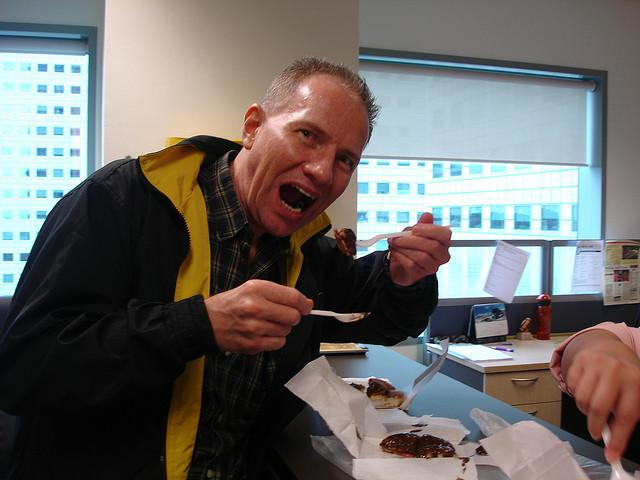

In [16]:
image

In [9]:
no_token

1939

In [8]:
yes_token

3869

Accuracy: 0.8600
Precision: 0.9091
Recall: 0.8000
F1-Score: 0.8511
Yes Ratio: 0.4400
Hallucination Rate: 0.0800


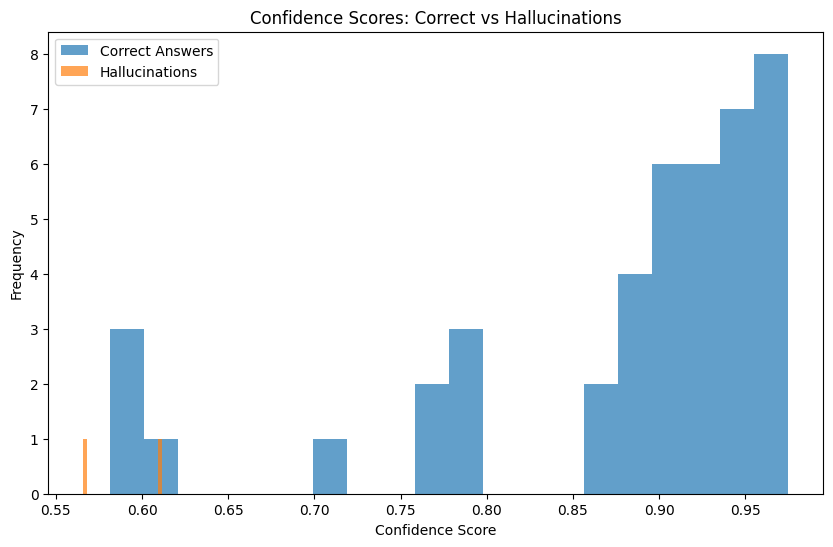

Hallucinations with confidence < 0.75: 2/2


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

if predictions and ground_truths and confidences:
    acc = accuracy_score(ground_truths, predictions)
    prec = precision_score(ground_truths, predictions, pos_label='yes')
    rec = recall_score(ground_truths, predictions, pos_label='yes')
    f1 = f1_score(ground_truths, predictions, pos_label='yes')

    yes_ratio = sum(1 for p in predictions if p == 'yes') / len(predictions)

    hallucinations = [i for i, (p, gt) in enumerate(zip(predictions, ground_truths)) if p == 'yes' and gt == 'no']
    hallucination_rate = len(hallucinations) / len([gt for gt in ground_truths if gt == 'no']) if ground_truths.count('no') > 0 else 0

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Yes Ratio: {yes_ratio:.4f}")
    print(f"Hallucination Rate: {hallucination_rate:.4f}")

    correct_conf = [confidences[i] for i in range(len(confidences)) if results[i]]
    halluc_conf = [confidences[i] for i in hallucinations]

    plt.figure(figsize=(10, 6))
    plt.hist(correct_conf, alpha=0.7, label='Correct Answers', bins=20)
    plt.hist(halluc_conf, alpha=0.7, label='Hallucinations', bins=20)
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Confidence Scores: Correct vs Hallucinations')
    plt.legend()
    plt.show()

    threshold = 0.75
    low_conf_halluc = sum(1 for i in hallucinations if confidences[i] < threshold)
    print(f"Hallucinations with confidence < {threshold}: {low_conf_halluc}/{len(hallucinations)}")
else:
    print("No data to calculate metrics.")

In [1]:
from datasets import load_dataset, Features, Value, Image

# The file names are hosted on the Hub, not locally at /content/.
# We pass the relative file names, and the loader will handle the download.
data_files = {
    'train': [
        'complex_reasoning_77k.json',
        'conversation_58k.json',
        'detail_23k.json',
        'llava_instruct_150k.json',
        'llava_instruct_80k.json',
        'llava_v1_5_mix665k.json',
    ]
}

# 3. Load the dataset by pointing to the repository and the specific files
# This is generally more robust for complex datasets composed of many files.
dataset = load_dataset(
    "liuhaotian/LLaVA-Instruct-150K",
    data_files=data_files, # Tell it exactly which files to load for the 'train' split
    split="train"
)

# 4. Cast Features to ensure consistency (Addresses the ArrowTypeError)
# We ensure 'id' is a string and 'image' is an Image object for uniform schema.
dataset = dataset.cast(Features({
    'id': Value('string'),
    'conversations': [
        {
            'from': Value('string'),
            'value': Value('string')
        }
    ],
    'image': Image(),
}))

# Limit to 500 samples
# Limit to 500 samples for fast testing, like your original code
dataset = dataset.select(range(min(500, len(dataset))))

# You must also ensure the 'image' column is loaded as an Image feature
# This is usually inferred, but can be a source of error.
dataset = dataset.cast(Features({
    'id': Value('string'),
    'conversations': [
        {
            'from': Value('string'),
            'value': Value('string')
        }
    ],
    'image': Image(),
}))


def format_data(examples):
    # The LLaVA-Instruct-150K uses 'conversations' and 'image' keys
    conversations = examples["conversations"]
    images = examples["image"]

    texts = [
        tokenizer.apply_chat_template(conv, tokenize=False, add_generation_prompt=False)
        for conv in conversations
    ]

    return {"text": texts, "image": images}

dataset = dataset.map(format_data, batched=True)

# # 4. Train
# trainer = SFTTrainer(
#     model=model,
#     tokenizer=tokenizer,
#     data_collator=UnslothVisionDataCollator(model, tokenizer),
#     train_dataset=dataset,
#     dataset_text_field="text", # Explicitly tell trainer where the text is
#     dataset_kwargs={"skip_prepare_dataset": True}, # Essential for Vision SFT
#     args=SFTConfig(
#         per_device_train_batch_size=2,
#         gradient_accumulation_steps=4,
#         warmup_steps=5,
#         max_steps=60,
#         learning_rate=2e-4, # LoRA standard LR
#         fp16=not is_bfloat16_supported(),
#         bf16=is_bfloat16_supported(),
#         logging_steps=1,
#         optim="adamw_8bit",
#         weight_decay=0.01,
#         lr_scheduler_type="linear",
#         seed=3407,
#         output_dir="outputs",
#         report_to="none",
#         remove_unused_columns=False,
#     ),
# )

# # Verify trainable parameters
# trainer.train()

# # 5. Save
# model.save_pretrained("lora_llava_model")
# tokenizer.save_pretrained("lora_llava_model")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split: 0 examples [00:00, ? examples/s]

DatasetGenerationError: An error occurred while generating the dataset

In [3]:
import torch
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTConfig
from datasets import load_dataset

# 1. Load Model (Same as before)
model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/llava-1.5-7b-hf",
    load_in_4bit=True,
    use_gradient_checkpointing="unsloth",
)

# 2. Add LoRA Adapters (Same as before)
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers=False,
    finetune_language_layers=True,
    finetune_attention_modules=True,
    finetune_mlp_modules=True,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)



==((====))==  Unsloth 2025.11.3: Fast Clip patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Making `model.base_model.model.model.language_model` require gradients
Unsloth: Making `model.base_model.model.model.language_model` require gradients


In [4]:
from trl import SFTTrainer, SFTConfig

# 4. Train
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=dataset,
    dataset_text_field="text", # Explicitly tell trainer where the text is
    dataset_kwargs={"skip_prepare_dataset": True}, # Essential for Vision SFT
    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        warmup_steps=5,
        max_steps=60,
        learning_rate=2e-4, # LoRA standard LR
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=1,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir="outputs",
        report_to="none",
        remove_unused_columns=False,
    ),
)

# Verify trainable parameters
trainer.train()

# 5. Save
model.save_pretrained("lora_llava_model")
tokenizer.save_pretrained("lora_llava_model")

NameError: name 'dataset' is not defined

In [5]:
import json
from PIL import Image
import os
import requests
from io import BytesIO
import torch.nn.functional as F

yes_token = processor.tokenizer.encode("Yes", add_special_tokens=False)[0]
no_token = processor.tokenizer.encode("No", add_special_tokens=False)[0]

pope_path = "/content/POPE/output/coco/coco_pope_random.json"
if not os.path.exists(pope_path):
    print("POPE file not found. Please check the repository structure.")
else:
    data = []
    with open(pope_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"Skipping invalid JSON line: {line.strip()} - Error: {e}")

    results = []
    predictions = []
    ground_truths = []
    confidences = []
    num_samples = min(50, len(data))  # Test on first 50

    for i, item in enumerate(data[:num_samples]):
        image_path = f"/content/val2014/{item['image']}"
        if not os.path.exists(image_path):
            url = f"http://images.cocodataset.org/val2014/{item['image']}"
            try:
                response = requests.get(url)
                image = Image.open(BytesIO(response.content))
                image.save(image_path)
            except:
                print(f"Failed to download {item['image']}, skipping.")
                continue
        else:
            image = Image.open(image_path)

        prompt = f"USER: <image>\n{item['text']} Answer with Yes or No.\nASSISTANT:"

        # Run Inference to get logits
        inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda" if torch.cuda.is_available() else "cpu")
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=1,
                return_dict_in_generate=True,
                output_scores=True,
                do_sample=False
            )

        # Get logits for the first generated token
        logits = outputs.scores[0][0]  # Shape: (vocab_size,)
        probs = F.softmax(logits, dim=-1)

        prob_yes = probs[yes_token].item()
        prob_no = probs[no_token].item()

        # Predicted token
        predicted_token = logits.argmax().item()
        if predicted_token == yes_token:
            prediction = "yes"
            confidence = prob_yes
        elif predicted_token == no_token:
            prediction = "no"
            confidence = prob_no
        else:
            # If neither, take the higher prob
            if prob_yes > prob_no:
                prediction = "yes"
                confidence = prob_yes
            else:
                prediction = "no"
                confidence = prob_no

        # Ground truth
        ground_truth = item['label']

        predictions.append(prediction)
        ground_truths.append(ground_truth)
        confidences.append(confidence)

        # Compare
        is_correct = (prediction == ground_truth)
        results.append(is_correct)

        if (i+1) % 10 == 0:
            print(f"Processed {i+1}/{num_samples} samples")

    accuracy = sum(results) / len(results) if results else 0
    print(f"Accuracy: {accuracy:.4f}")

Processed 10/50 samples
Processed 20/50 samples
Processed 30/50 samples
Processed 40/50 samples
Processed 50/50 samples
Accuracy: 0.8600


Accuracy: 0.8600
Precision: 0.9091
Recall: 0.8000
F1-Score: 0.8511
Yes Ratio: 0.4400
Hallucination Rate: 0.0800


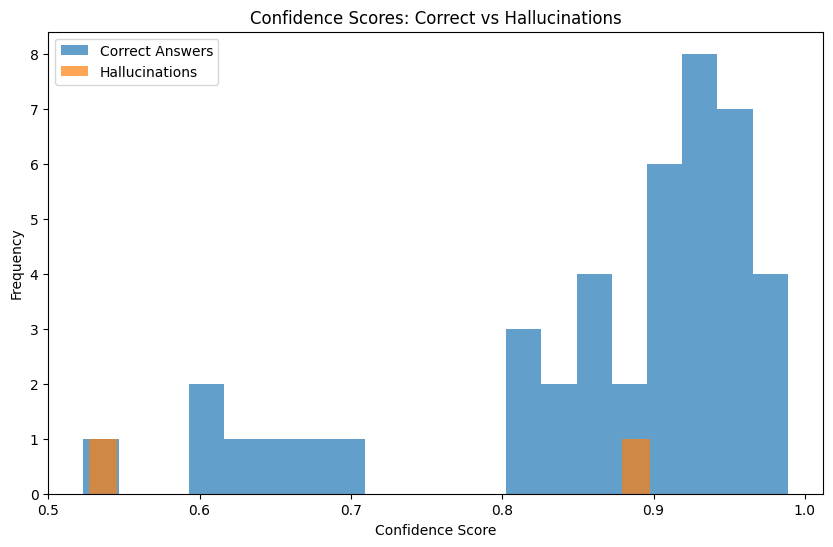

Hallucinations with confidence < 0.75: 1/2


In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

if predictions and ground_truths and confidences:
    acc = accuracy_score(ground_truths, predictions)
    prec = precision_score(ground_truths, predictions, pos_label='yes')
    rec = recall_score(ground_truths, predictions, pos_label='yes')
    f1 = f1_score(ground_truths, predictions, pos_label='yes')

    yes_ratio = sum(1 for p in predictions if p == 'yes') / len(predictions)

    hallucinations = [i for i, (p, gt) in enumerate(zip(predictions, ground_truths)) if p == 'yes' and gt == 'no']
    hallucination_rate = len(hallucinations) / len([gt for gt in ground_truths if gt == 'no']) if ground_truths.count('no') > 0 else 0

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Yes Ratio: {yes_ratio:.4f}")
    print(f"Hallucination Rate: {hallucination_rate:.4f}")

    correct_conf = [confidences[i] for i in range(len(confidences)) if results[i]]
    halluc_conf = [confidences[i] for i in hallucinations]

    plt.figure(figsize=(10, 6))
    plt.hist(correct_conf, alpha=0.7, label='Correct Answers', bins=20)
    plt.hist(halluc_conf, alpha=0.7, label='Hallucinations', bins=20)
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Confidence Scores: Correct vs Hallucinations')
    plt.legend()
    plt.show()

    threshold = 0.75
    low_conf_halluc = sum(1 for i in hallucinations if confidences[i] < threshold)
    print(f"Hallucinations with confidence < {threshold}: {low_conf_halluc}/{len(hallucinations)}")
else:
    print("No data to calculate metrics.")

In [2]:
import torch
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset



class GRPO_SFTTrainer(SFTTrainer):
    # Add **kwargs to accept Unsloth's extra arguments like num_items_in_batch
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        batch_size = inputs["input_ids"].shape[0]
        half_batch = batch_size // 2

        if batch_size % 2 != 0 or half_batch == 0:
            print("Warning: Batch size must be even and >= 2 for GRPO loss. Falling back to standard CE loss.")
            # Ensure to pass kwargs to the parent class if falling back
            return super().compute_loss(model, inputs, return_outputs=return_outputs, **kwargs)

        # 1. Run forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        labels = inputs.get("labels")

        # 2. Manual Cross-Entropy Loss Calculation (Per-Sample)
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')

        # Shift logits and labels for language modeling
        shifted_logits = logits[..., :-1, :].contiguous()
        shifted_labels = labels[..., 1:].contiguous()

        # Compute loss per token
        loss = loss_fct(shifted_logits.view(-1, shifted_logits.size(-1)), shifted_labels.view(-1))

        # Reshape and calculate per-sample average loss
        sequence_length = shifted_labels.size(1)
        loss = loss.view(batch_size, sequence_length)
        valid_tokens = (shifted_labels != -100).sum(dim=1)
        per_sample_loss = (loss * (shifted_labels != -100)).sum(dim=1) / valid_tokens.clamp(min=1)

        # 3. Split losses into Positive and Negative groups
        L_pos = per_sample_loss[:half_batch]
        L_neg = per_sample_loss[half_batch:]

        # 4. Calculate the GRPO Ranking Loss
        ranking_margin = 0.5
        lambda_rank = 0.1

        # GRPO Ranking Loss: max(0, L_pos - L_neg + margin)
        ranking_loss = torch.relu(L_pos - L_neg + ranking_margin).mean()

        # 5. Calculate the Total Loss
        average_ce_loss = per_sample_loss.mean()
        total_loss = average_ce_loss + (lambda_rank * ranking_loss)

        if return_outputs:
            return (total_loss, outputs)
        return total_loss

In [6]:
import torch
import os
import json
from PIL import Image
from unsloth import FastVisionModel, is_bfloat16_supported
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset, Dataset
from io import BytesIO # Required if fetching images, but we use local paths here
from typing import List, Dict, Any

# Define the local paths based on your download script
POPE_FILE_PATH = "/content/POPE/output/coco/coco_pope_random.json"
COCO_IMAGE_DIR = "/content/val2014"
BASE_MODEL_ID = "unsloth/llava-1.5-7b-hf"
# --- Corrected and Definitive Conversion Function ---
# --- Corrected and Definitive Conversion Function (V3) ---
# --- Corrected Conversion Function (V4: Simple LLaVA-style) ---
def convert_pope_to_llava_format(pope_data_path: str, image_dir: str) -> List[Dict[str, Any]]:
    """Converts the POPE JSON file into LLaVA format using the simple <image> token."""
    print(f"Reading POPE data from {pope_data_path}...")

    with open(pope_data_path, 'r') as f:
        pope_list = [json.loads(line) for line in f]

    llava_data = []

    for item in pope_list:
        image_path = os.path.join(image_dir, item['image'])
        if not os.path.exists(image_path): continue

        try:
            image = Image.open(image_path).convert("RGB")
        except:
            continue

        # FIX: Use the simple 'role' and 'content' structure with the <image> token.
        conversation = [
            {
                "role": "user",
                # Insert the <image> token directly into the content string.
                "content": f"<image>\n{item['text']} Answer with Yes or No."
            },
            {
                "role": "assistant",
                "content": item['label'] # Simple text response
            },
        ]

        llava_data.append({
            "id": item['question_id'],
            "conversations": conversation,
            "image": image
        })

    print(f"Successfully converted {len(llava_data)} POPE samples for training.")
    return llava_data

# --- The format_data function must also be updated to match the simpler structure ---
def format_data(examples):
    conversations = examples["conversations"]
    images = examples["image"]

    texts = []
    for conv in conversations:
        # The structure is now a list of simple dicts, not nested lists.
        # This will bypass the complex multimodal Jinja logic that caused the previous errors.
        texts.append(
            tokenizer.apply_chat_template([conv], tokenize=False, add_generation_prompt=False)
        )

    return {"text": texts, "image": images}
# ... (The rest of your script, including model loading, follows)# --- The rest of your script execution ---
# 1. RE-DEFINE THE FUNCTION (run the cell containing the corrected definition)
# 2. Re-create the data list:
pope_llava_data = convert_pope_to_llava_format(POPE_FILE_PATH, COCO_IMAGE_DIR)
dataset = Dataset.from_list(pope_llava_data)
dataset = dataset.select(range(min(500, len(dataset))))
dataset = dataset.map(format_data, batched=False)
# ... (Training continues)# -------------------------------------------------------------------
# 4. Training

# Remember, if you use a custom GRPO trainer, you MUST set the environment variable here
# os.environ['UNSLOTH_RETURN_LOGITS'] = '1'
# Set the mode to offline


Reading POPE data from /content/POPE/output/coco/coco_pope_random.json...
Successfully converted 54 POPE samples for training.


Map:   0%|          | 0/54 [00:00<?, ? examples/s]

In [7]:
import os
import wandb

os.environ["WANDB_MODE"] = "offline"
# -------------------------------------------------------------------
print("Setting up and starting training on POPE-derived data...")
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    data_collator=UnslothVisionDataCollator(model, tokenizer),
    train_dataset=dataset,
    dataset_text_field="text",
    dataset_kwargs={"skip_prepare_dataset": True},
    args=SFTConfig(
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        max_steps=200,
        learning_rate=2e-4,
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        output_dir="outputs_pope_ft",
        remove_unused_columns=False,
        report_to="none",
    ),
)

# The initialization will now be instantaneous and local
wandb.init(project="your_llava_project")
trainer.train()

# 5. Save
model.save_pretrained("lora_llava_pope_ft")
tokenizer.save_pretrained("lora_llava_pope_ft")

Setting up and starting training on POPE-derived data...


The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 54 | Num Epochs = 29 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 39,976,960 of 7,103,404,032 (0.56% trained)


Step,Training Loss


Step,Training Loss
10,5.601400
20,2.432000
30,0.454300
40,0.192300
50,0.156600
60,0.147600
70,0.146700


KeyboardInterrupt: 

In [32]:


tokenizer.apply_chat_template(,tokenize=False, add_generation_prompt=False)

SyntaxError: invalid syntax (ipython-input-3739884068.py, line 4)

In [10]:
import json
from PIL import Image
import os
import requests
from io import BytesIO
import torch.nn.functional as F

yes_token = processor.tokenizer.encode("Yes", add_special_tokens=False)[0]
no_token = processor.tokenizer.encode("No", add_special_tokens=False)[0]

pope_path = "/content/POPE/output/coco/coco_pope_random.json"
if not os.path.exists(pope_path):
    print("POPE file not found. Please check the repository structure.")
else:
    data = []
    with open(pope_path, 'r') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError as e:
                print(f"Skipping invalid JSON line: {line.strip()} - Error: {e}")

    results = []
    predictions = []
    ground_truths = []
    confidences = []
    num_samples = min(50, len(data))  # Test on first 50

    for i, item in enumerate(data[:num_samples]):
        image_path = f"/content/val2014/{item['image']}"
        if not os.path.exists(image_path):
            url = f"http://images.cocodataset.org/val2014/{item['image']}"
            try:
                response = requests.get(url)
                image = Image.open(BytesIO(response.content))
                image.save(image_path)
            except:
                print(f"Failed to download {item['image']}, skipping.")
                continue
        else:
            image = Image.open(image_path)

        prompt = f"USER: <image>\n{item['text']} Answer with Yes or No.\nASSISTANT:"

        # Run Inference to get logits
        inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda" if torch.cuda.is_available() else "cpu")
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=1,
                return_dict_in_generate=True,
                output_scores=True,
                do_sample=False
            )

        # Get logits for the first generated token
        logits = outputs.scores[0][0]  # Shape: (vocab_size,)
        probs = F.softmax(logits, dim=-1)

        prob_yes = probs[yes_token].item()
        prob_no = probs[no_token].item()

        # Predicted token
        predicted_token = logits.argmax().item()
        if predicted_token == yes_token:
            prediction = "yes"
            confidence = prob_yes
        elif predicted_token == no_token:
            prediction = "no"
            confidence = prob_no
        else:
            # If neither, take the higher prob
            if prob_yes > prob_no:
                prediction = "yes"
                confidence = prob_yes
            else:
                prediction = "no"
                confidence = prob_no

        # Ground truth
        ground_truth = item['label']

        predictions.append(prediction)
        ground_truths.append(ground_truth)
        confidences.append(confidence)

        # Compare
        is_correct = (prediction == ground_truth)
        results.append(is_correct)

        if (i+1) % 10 == 0:
            print(f"Processed {i+1}/{num_samples} samples")

    accuracy = sum(results) / len(results) if results else 0
    print(f"Accuracy: {accuracy:.4f}")

Processed 10/50 samples
Processed 20/50 samples
Processed 30/50 samples
Processed 40/50 samples
Processed 50/50 samples
Accuracy: 0.8200


Accuracy: 0.8200
Precision: 0.9444
Recall: 0.6800
F1-Score: 0.7907
Yes Ratio: 0.3600
Hallucination Rate: 0.0400


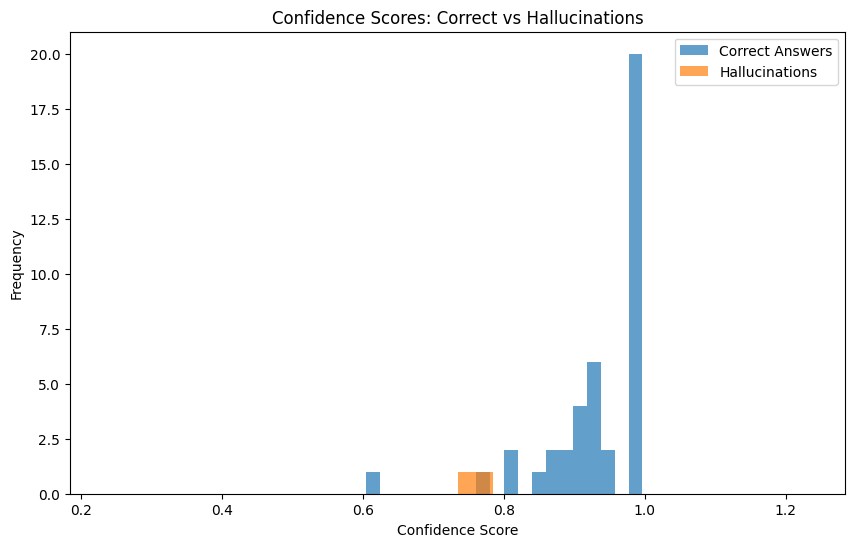

Hallucinations with confidence < 0.75: 1/1


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

if predictions and ground_truths and confidences:
    acc = accuracy_score(ground_truths, predictions)
    prec = precision_score(ground_truths, predictions, pos_label='yes')
    rec = recall_score(ground_truths, predictions, pos_label='yes')
    f1 = f1_score(ground_truths, predictions, pos_label='yes')

    yes_ratio = sum(1 for p in predictions if p == 'yes') / len(predictions)

    hallucinations = [i for i, (p, gt) in enumerate(zip(predictions, ground_truths)) if p == 'yes' and gt == 'no']
    hallucination_rate = len(hallucinations) / len([gt for gt in ground_truths if gt == 'no']) if ground_truths.count('no') > 0 else 0

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Yes Ratio: {yes_ratio:.4f}")
    print(f"Hallucination Rate: {hallucination_rate:.4f}")

    correct_conf = [confidences[i] for i in range(len(confidences)) if results[i]]
    halluc_conf = [confidences[i] for i in hallucinations]

    plt.figure(figsize=(10, 6))
    plt.hist(correct_conf, alpha=0.7, label='Correct Answers', bins=20)
    plt.hist(halluc_conf, alpha=0.7, label='Hallucinations', bins=20)
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Confidence Scores: Correct vs Hallucinations')
    plt.legend()
    plt.show()

    threshold = 0.75
    low_conf_halluc = sum(1 for i in hallucinations if confidences[i] < threshold)
    print(f"Hallucinations with confidence < {threshold}: {low_conf_halluc}/{len(hallucinations)}")
else:
    print("No data to calculate metrics.")